# ⚽ Player Value Prediction & Analysis – Model Training

## 📌 Objective

The goal of this notebook is to train and evaluate multiple machine learning models to predict player market value based on performance, physical attributes, and other relevant features.

---

## 🧠 Approach

This notebook follows a structured machine learning workflow:

1. Load the cleaned dataset
2. Perform train-test split to avoid data leakage
3. Apply encoding on categorical features (fitted on training data only)
4. Apply scaling where required
5. Perform feature selection (based on training data)
6. Train multiple models and compare performance
7. Evaluate models using appropriate metrics

---

## ⚠️ Important Considerations

* All transformations (encoding, scaling, feature selection) are performed **only on training data** and then applied to test data
* This ensures there is **no data leakage**
* The workflow is designed to mimic **real-world machine learning pipelines**

---

## 🤖 Models to be Evaluated

* Linear Regression (MLR)
* Polynomial Regression
* Decision Tree (with pruning)
* Random Forest

---

## 🎯 Outcome

* Identify the best-performing model
* Save the trained model and preprocessing objects
* Prepare the model for deployment and further use in a recommendation system

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
df=pd.read_csv("cleaned_fifa.csv")

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,Name,Nationality,Age,↓OVA,POT,Club,Positions,Height_cm,Weight_kg,Preferred Foot,BOV,Best Position,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits,Contract_Start,Contract_End,Joined_year,Years_at_club
0,L. Messi,Argentina,33,93,93,FC Barcelona,"RW, ST, CF",170,72,Left,93,RW,103500000.0,560000.0,138400000.0,429,85,95,70,91,88,470,96,93,94,91,96,451,91,80,91,94,95,389,86,68,72,69,94,347,44,40,93,95,75,96,91,32,35,24,54,6,11,15,14,8,2231,466,4,4,Medium,Low,5,85,92,91,95,38,65,771.0,2004.0,2021.0,2004,22
1,Cristiano Ronaldo,Portugal,35,92,92,Juventus,"ST, LW",187,83,Right,92,ST,63000000.0,220000.0,75900000.0,437,84,95,90,82,86,414,88,81,76,77,92,431,87,91,87,95,71,444,94,95,84,78,93,353,63,29,95,82,84,95,84,28,32,24,58,7,11,15,14,11,2221,464,4,5,High,Low,5,89,93,81,89,35,77,562.0,2018.0,2022.0,2018,8
2,J. Oblak,Slovenia,27,91,93,Atlético Madrid,GK,188,87,Right,91,GK,120000000.0,125000.0,159400000.0,95,13,11,15,43,13,109,12,13,14,40,30,307,43,60,67,88,49,268,59,78,41,78,12,140,34,19,11,65,11,68,57,27,12,18,437,87,92,78,90,90,1413,489,3,1,Medium,Medium,3,87,92,78,90,52,90,150.0,2014.0,2023.0,2014,12
3,K. De Bruyne,Belgium,29,91,91,Manchester City,"CAM, CM",181,70,Right,91,CAM,129000000.0,370000.0,161000000.0,407,94,82,55,94,82,441,88,85,83,93,92,398,77,76,78,91,76,408,91,63,89,74,91,408,76,66,88,94,84,91,186,68,65,53,56,15,13,5,10,13,2304,485,5,4,High,High,4,76,86,93,88,64,78,207.0,2015.0,2023.0,2015,11
4,Neymar Jr,Brazil,28,91,91,Paris Saint-Germain,"LW, CAM",175,68,Right,91,LW,132000000.0,270000.0,166500000.0,408,85,87,62,87,87,448,95,88,89,81,95,453,94,89,96,91,83,357,80,62,81,50,84,356,51,36,87,90,92,93,94,35,30,29,59,9,9,15,15,11,2175,451,5,5,High,Medium,5,91,85,86,94,36,59,595.0,2017.0,2022.0,2017,9


## Feature Leakage Analysis

Correlation analysis revealed that:

- ***Release Clause*** has a correlation of ***0.96*** with the target variable (Value), indicating an almost direct linear relationship.
- ***Wage*** has a correlation of ***0.81***, showing strong dependency on Value.

Release Clause is effectively derived from the player's market value, making it a direct leakage feature. Wage, while not directly derived, is still heavily influenced by player value and acts as a proxy.

Including these features would allow the model to learn trivial relationships instead of meaningful patterns.

### Final Decision:
Both features were removed to prevent data leakage and ensure realistic model performance.

In [4]:
corr = df.corr(numeric_only=True)["Value"].sort_values(ascending=False)
print(corr[["Value", "Release Clause", "Wage"]])

df = df.drop(["Release Clause", "Wage"], axis=1)


Value             1.00000
Release Clause    0.96644
Wage              0.81487
Name: Value, dtype: float64


## Feature Selection Based on Real-World Perspective

Instead of relying on aggregated features such as Overall rating or Total Stats, we selected features that reflect how a football club manager evaluates a player in real life.

A manager considers:
- Physical attributes (height, strength, stamina)
- Technical skills (passing, dribbling, finishing)
- Mental abilities (vision, composure, positioning)
- Player profile (age, experience, position)

Aggregated features like Overall and Total Stats were removed because they are derived metrics that summarize these individual attributes. Including them would make the prediction task trivial and unrealistic.

By using raw player attributes, the model learns meaningful patterns similar to real-world decision-making.

In [5]:
cols_to_drop = ["↓OVA", "POT", "BOV", "Total Stats", "Base Stats","Joined_year"]
df = df.drop(cols_to_drop, axis=1)

# 🧠 Train-Test Split Before Imputation

## ❓ Why split the data first?

Before applying any data-driven transformation such as ***KNN imputation***, it is essential to split the dataset into training and testing sets.
## ⚙️ Why is this important?

***KNN Imputer*** uses feature similarity across data points to estimate missing values
If applied on the entire dataset, information from the test set may influence the imputed values
This leads to data leakage, where the model indirectly gains access to unseen data

## 🛡️ What does splitting ensure?

The test set remains completely unseen during training
All preprocessing steps (imputation, encoding, scaling) are learned only from training data
The model evaluation becomes realistic and reliable

## 🧠 Key Principle
Any transformation that learns patterns from data must be fitted only on the training set and then applied to the test set.
This ensures that the pipeline closely mimics real-world scenarios where future data is unknown.

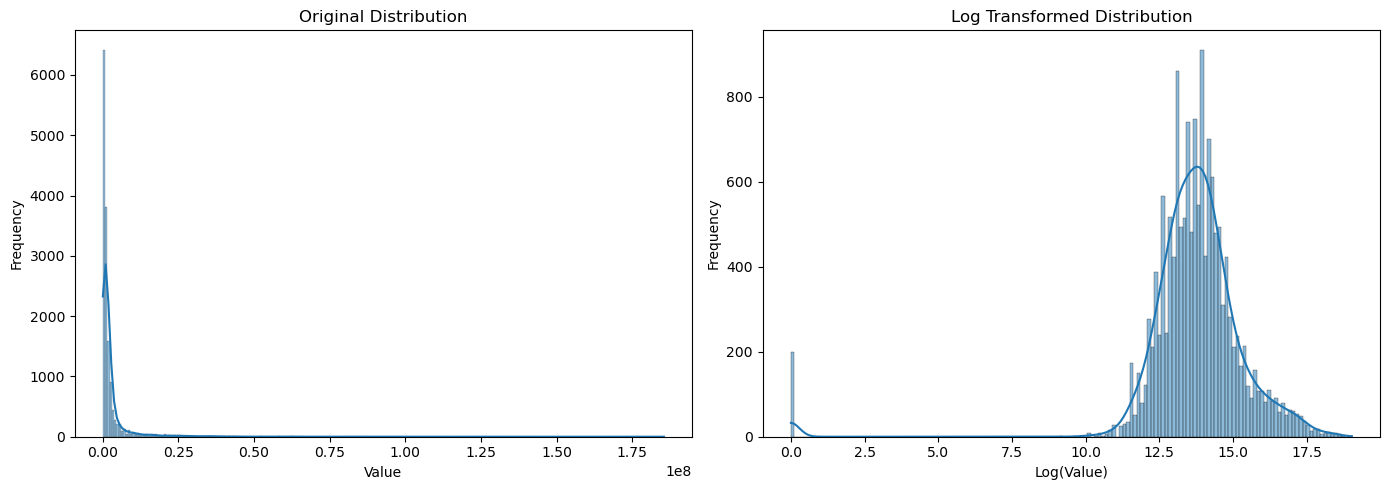

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

X = df.drop("Value", axis=1)
y = df["Value"]

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create figure with 2 plots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 🔹 Original distribution
sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title("Original Distribution")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")

# 🔹 Log transformed distribution
y_train = np.log1p(y_train)
y_test=np.log1p(y_test)

sns.histplot(y_train, kde=True, ax=axes[1])
axes[1].set_title("Log Transformed Distribution")
axes[1].set_xlabel("Log(Value)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 📉 Log Transformation of Target Variable (Value)

The target variable Value exhibits a right-skewed distribution, where a small number of players have extremely high market values while the majority have relatively low values. This imbalance can negatively impact model performance.
Applying a log transformation helps to:
Reduce skewness by compressing large values
Stabilize variance across the dataset
Improve the model’s ability to learn patterns effectively
Prevent the model from being overly influenced by extreme outliers
As a result, the transformed target becomes more evenly distributed, leading to better generalization and more reliable predictions

## 🧠 Handling Missing Values in Contract Features (KNN Imputation)

### ❓ Why is imputation needed?

The `Contract_start` and `Contract_end` features contain missing values, which can negatively impact model performance and prevent certain algorithms from working properly. Dropping these rows would lead to unnecessary data loss, especially when other useful player attributes are available.

---

### ⚙️ Why KNN Imputer?

Instead of using simple strategies like mean or median imputation, we use **K-Nearest Neighbors (KNN) Imputation** because:

* It preserves **data relationships** by imputing values based on similar players
* It leverages multiple features (e.g., age, overall rating, value, etc.) to estimate realistic contract periods
* It produces more **context-aware and accurate imputations** compared to global statistics

In a dataset like FIFA players, where attributes are highly correlated, KNN provides a **more intelligent approximation** of missing values.

---

### 🛠️ How is it applied?

* KNN Imputer is applied only on relevant numerical features
* The imputer identifies similar players based on feature similarity
* Missing contract values are filled using the average of nearest neighbors

This ensures that imputed values are **consistent with player profiles** rather than arbitrary estimates.


In [7]:
# Select features for imputation

features_for_imputation = ["Contract_Start","Contract_End"]

# Initialize imputer

imputer = KNNImputer(n_neighbors=5)

# Fit ONLY on training data

X_train[features_for_imputation] = imputer.fit_transform(X_train[features_for_imputation])

# Transform test data

X_test[features_for_imputation] = imputer.transform(X_test[features_for_imputation])

In [8]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15183 entries, 4721 to 5994
Data columns (total 65 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              15183 non-null  object 
 1   Nationality       15183 non-null  object 
 2   Age               15183 non-null  int64  
 3   Club              15183 non-null  object 
 4   Positions         15183 non-null  object 
 5   Height_cm         15183 non-null  int64  
 6   Weight_kg         15183 non-null  int64  
 7   Preferred Foot    15183 non-null  object 
 8   Best Position     15183 non-null  object 
 9   Attacking         15183 non-null  int64  
 10  Crossing          15183 non-null  int64  
 11  Finishing         15183 non-null  int64  
 12  Heading Accuracy  15183 non-null  int64  
 13  Short Passing     15183 non-null  int64  
 14  Volleys           15183 non-null  int64  
 15  Skill             15183 non-null  int64  
 16  Dribbling         15183 non-null  int64  
 

### 🔄 One-Hot Encoding using Scikit-learn: Preferred Foot

The Preferred Foot column is a categorical feature containing values like "Left" and "Right", which cannot be directly used by Machine Learning models.
Instead of using pandas, we use ***Scikit-learn (OneHotEncoder)*** because:
It integrates seamlessly with pipelines, ensuring proper preprocessing during training and testing
It prevents data leakage by allowing fitting only on training data
It ensures consistent transformations when the model is deployed
It provides better control over encoding (e.g., handling unknown categories)

In [9]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

X_train_encoded = ohe.fit_transform(X_train[['Preferred Foot']])
X_test_encoded = ohe.transform(X_test[['Preferred Foot']])

train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=ohe.get_feature_names_out(['Preferred Foot']),
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=ohe.get_feature_names_out(['Preferred Foot']),
    index=X_test.index
)

X_train = pd.concat([X_train.drop('Preferred Foot', axis=1), train_encoded_df], axis=1)
X_test = pd.concat([X_test.drop('Preferred Foot', axis=1), test_encoded_df], axis=1)

### 🔢 Ordinal Encoding: Attacking Work Rate (A/W) and Defensive Work Rate (D/W)

The A/W (Attacking Work Rate) and D/W (Defensive Work Rate) features contain categorical values such as "Low", "Medium", and "High", which have a clear inherent order.
Unlike nominal categories, these values represent levels of intensity, so using Ordinal Encoding preserves this meaningful ranking:
Low < Medium < High
We use ***Scikit-learn (OrdinalEncoder)*** because:
It maintains the ordinal relationship between categories
It integrates well with pipelines for consistent preprocessing
It avoids incorrect assumptions that would arise from one-hot encoding in this case

In [10]:
from sklearn.preprocessing import OrdinalEncoder

# Define order
categories = [['Low', 'Medium', 'High']]

encoder = OrdinalEncoder(categories=categories)

# Fit on training data
X_train[['A/W']] = encoder.fit_transform(X_train[['A/W']])
X_test[['A/W']] = encoder.transform(X_test[['A/W']])

# Important: reinitialize for D/W (separate column)
encoder_dw = OrdinalEncoder(categories=categories)

X_train[['D/W']] = encoder_dw.fit_transform(X_train[['D/W']])
X_test[['D/W']] = encoder_dw.transform(X_test[['D/W']])

In [11]:
import category_encoders as ce

encoder = ce.TargetEncoder(cols=['Club', 'Best Position'])

# Fit only on training data
X_train[['Club', 'Best Position']] = encoder.fit_transform(
    X_train[['Club', 'Best Position']], y_train
)

# Transform test data
X_test[['Club', 'Best Position']] = encoder.transform(
    X_test[['Club', 'Best Position']]
)

### 🧹 Removing Redundant Feature: Positions

The Positions column contains multiple positional roles for a player, which introduces complexity and redundancy after encoding the Best Position feature.
Since Best Position already captures the player’s primary role in a structured and model-friendly format, keeping the Positions column would:
Introduce duplicate information
Increase noise and dimensionality
Make preprocessing more complex due to multi-value entries
Removing this column ensures that the dataset remains clean, consistent, and focused on the most relevant features, improving model efficiency and performance.

In [12]:
X_train = X_train.drop(columns=['Positions'])
X_test = X_test.drop(columns=['Positions'])

In [13]:
## we are keeping names because maybe we will create a recommendation system later can be useful at that time

player_names_train = X_train['Name']
player_names_test = X_test['Name']

X_train = X_train.drop(columns=['Name'])
X_test = X_test.drop(columns=['Name'])

### 📊 Feature Evaluation: Nationality (Correlation & Impact)

Before removing the Nationality feature, it is important to verify whether it contributes meaningful information to the model.
Since Nationality is a categorical variable, it cannot be directly evaluated using standard correlation methods. Therefore, we encode it and analyze its relationship with the target variable (Value) to determine its usefulness.
If the feature shows low correlation or weak predictive power, it can be safely removed to reduce noise and improve model performance

In [14]:
from sklearn.preprocessing import OrdinalEncoder

temp_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_nat = X_train.copy()
X_test_nat = X_test.copy()

X_train_nat[['Nationality']] = temp_encoder.fit_transform(X_train_nat[['Nationality']])
X_test_nat[['Nationality']] = temp_encoder.transform(X_test_nat[['Nationality']])

In [15]:

temp_df = X_train_nat.copy()
temp_df['Value'] = y_train

# Compute correlation
correlation = temp_df.corr(numeric_only=True)['Value'].sort_values(ascending=False)

print(correlation['Nationality'])

-0.029866779544463547


### 🌍 Feature Removal: Nationality

After encoding and evaluating the Nationality feature, its correlation with the target variable (Value) was found to be approximately ***-0.03***, which is very ***close to zero***.
This indicates that Nationality has no significant relationship with player market value and does not contribute meaningful information for prediction.
Keeping such a feature would:
Introduce noise into the model
Increase unnecessary complexity
Potentially reduce model performance
Therefore, the Nationality column is removed to ensure a more efficient and relevant feature set.

In [16]:
X_train = X_train.drop(columns=['Nationality'])
X_test = X_test.drop(columns=['Nationality'])

# here even domain knowledge comes in mind as we know nationality doesnt effect how a player plays and what its value might be 

## 🔍 Why StandardScaler instead of MinMaxScaler?

### ✅ Why we use StandardScaler

**StandardScaler** transforms features so that they have:
- Mean = 0  
- Standard Deviation = 1  

This is done using:

\[
z = \frac{x - \mu}{\sigma}
\]

### 💡 Key Reasons

1. **Handles Outliers Better**
   - StandardScaler does not compress all values into a fixed range.
   - Extreme values (outliers) still exist but do not distort the entire feature distribution.

2. **Works Well with Many ML Algorithms**
   - Algorithms like:
     - Linear Regression
     - Logistic Regression
     - SVM
     - KNN  
   perform better when features are centered around zero.

3. **Maintains Distribution Shape**
   - It preserves the original distribution (just shifts and scales it).
   - Useful when data is approximately Gaussian.

---

### ❌ Why NOT MinMaxScaler

**MinMaxScaler** scales data to a fixed range [0, 1]:

\[
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
\]

### 🚫 Limitations

1. **Highly Sensitive to Outliers**
   - A single extreme value can shrink all other values into a very small range.
   - This reduces the model’s ability to learn meaningful patterns.

2. **Distorts Feature Distribution**
   - Does not preserve the original distribution of data.

3. **Not Ideal for Real-World Noisy Data**
   - In datasets like football player stats or prices, outliers are common.
   - MinMaxScaler can make the model unstable in such cases.

---

### 🧠 Conclusion

We use **StandardScaler** because:
- It is more robust to outliers  
- It works well with most machine learning algorithms  
- It maintains the statistical properties of the data  

Hence, it is a better choice for this dataset.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Why K-Fold Cross Validation?

Instead of relying on a single train-test split, K-Fold Cross Validation:

- Splits the data into K parts (folds)
- Trains on K-1 folds and tests on the remaining fold
- Repeats this process K times

### Benefits:
- More reliable performance estimate
- Reduces variance due to random splitting
- Uses entire dataset efficiently

Hence, it provides a more robust evaluation of the model.

## Why Adjusted R²?

R² score increases whenever we add more features, even if they are useless.

Adjusted R² solves this by penalizing unnecessary features:

\[
Adjusted\ R^2 = 1 - \left( \frac{(1 - R^2)(n - 1)}{n - p - 1} \right)
\]

Where:
- n = number of samples
- p = number of features

### Benefits:
- Prevents overfitting
- Gives a more realistic performance measure
- Useful when comparing models with different number of features

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

# Initialize model
model = LinearRegression()

# K-Fold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []
adj_r2_scores = []

n = X_train_scaled.shape[0]
p = X_train_scaled.shape[1]

for train_index, val_index in kf.split(X_train_scaled):
    X_train_fold, X_val_fold = X_train_scaled[train_index], X_train_scaled[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train
    model.fit(X_train_fold, y_train_fold)

    # Predict
    y_pred = model.predict(X_val_fold)

    # R2
    r2 = r2_score(y_val_fold, y_pred)
    r2_scores.append(r2)

    # Adjusted R2
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    adj_r2_scores.append(adj_r2)

# Results
print("R2 Scores:", r2_scores)
print("Mean R2:", np.mean(r2_scores))

print("Adjusted R2 Scores:", adj_r2_scores)
print("Mean Adjusted R2:", np.mean(adj_r2_scores))

R2 Scores: [0.9448720798766547, 0.9104989582555476, 0.8732487943798545, 0.9269448669805127, 0.9154121079615101]
Mean R2: 0.9141953614908159
Adjusted R2 Scores: [0.9446460262359373, 0.9101319566293468, 0.8727290473726819, 0.9266453022816232, 0.9150652528486538]
Mean Adjusted R2: 0.9138435170736485


In [19]:
print(X_train.columns)

Index(['Age', 'Club', 'Height_cm', 'Weight_kg', 'Best Position', 'Attacking',
       'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing', 'Volleys',
       'Skill', 'Dribbling', 'Curve', 'FK Accuracy', 'Long Passing',
       'Ball Control', 'Movement', 'Acceleration', 'Sprint Speed', 'Agility',
       'Reactions', 'Balance', 'Power', 'Shot Power', 'Jumping', 'Stamina',
       'Strength', 'Long Shots', 'Mentality', 'Aggression', 'Interceptions',
       'Positioning', 'Vision', 'Penalties', 'Composure', 'Defending',
       'Marking', 'Standing Tackle', 'Sliding Tackle', 'Goalkeeping',
       'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning',
       'GK Reflexes', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'PAC', 'SHO', 'PAS',
       'DRI', 'DEF', 'PHY', 'Hits', 'Contract_Start', 'Contract_End',
       'Years_at_club', 'Preferred Foot_Right'],
      dtype='object')


In [20]:
model.fit(X_train_scaled, y_train)

# Get coefficients
coefficients = model.coef_

# Map with feature names
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coefficients
})

# Sort by importance
feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

print(feature_importance) 

           Feature  Coefficient
1             Club     1.583182
54             DRI     0.314528
21       Reactions     0.289468
56             PHY     0.275116
51             PAC     0.217361
..             ...          ...
30      Aggression    -0.090888
39  Sliding Tackle    -0.102861
32     Positioning    -0.103455
12       Dribbling    -0.257263
0              Age    -0.353691

[62 rows x 2 columns]


## Final Decision on Multicollinearity

The dataset contains natural correlations among features due to the nature of football player attributes.

While VIF analysis revealed multicollinearity, further feature removal would lead to loss of important information.

The primary objective of this project is prediction.

Additionally, tree-based models such as Random Forest will be used, which are robust to multicollinearity.

## Feature Selection using Lasso Regression

Lasso Regression (L1 regularization) was applied to perform both regression and feature selection simultaneously. Unlike traditional linear models, Lasso introduces a penalty term proportional to the absolute values of the coefficients, which encourages sparsity in the model.

This results in some feature coefficients being reduced exactly to zero, effectively removing less important or redundant features from the model.

To ensure proper functioning of Lasso, all features were scaled prior to training, as regularization is sensitive to feature magnitudes.

Different values of the regularization parameter (alpha) were explored to control the strength of feature elimination. A high alpha led to excessive feature removal, while a lower alpha retained more features. To avoid manual tuning, LassoCV was also used to automatically select the optimal alpha using cross-validation.

The resulting model provided insights into:

* Which features have the strongest influence on the target variable
* Which features can be safely ignored (coefficients equal to zero)

This improved interpretability and reduced model complexity, making the feature set more efficient for further modeling.


In [21]:
from sklearn.linear_model import Lasso

# 🔹 Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []
adj_r2_scores = []

n_features = X_train_scaled.shape[1]

for train_idx, val_idx in kf.split(X_train_scaled):
    
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # 🔹 Lasso model
    model = Lasso(alpha=0.001, random_state=42)
    model.fit(X_tr, y_tr)
    
    y_pred = model.predict(X_val)
    
    # 🔹 R2
    r2 = r2_score(y_val, y_pred)
    r2_scores.append(r2)
    
    # 🔹 Adjusted R2
    n_samples = len(y_val)
    
    adj_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)
    adj_r2_scores.append(adj_r2)

# 🔹 Results
print("R2 Scores:", r2_scores)
print("Mean R2:", np.mean(r2_scores))

print("\nAdjusted R2 Scores:", adj_r2_scores)
print("Mean Adjusted R2:", np.mean(adj_r2_scores))

R2 Scores: [0.9447988639644235, 0.9106724384263124, 0.8733230799149, 0.9267994544848445, 0.9153227109856]
Mean R2: 0.914183309555216

Adjusted R2 Scores: [0.9436480669118997, 0.9088101960532228, 0.8706822026300055, 0.9252729042588305, 0.91355682066643]
Mean Adjusted R2: 0.9123940381040777


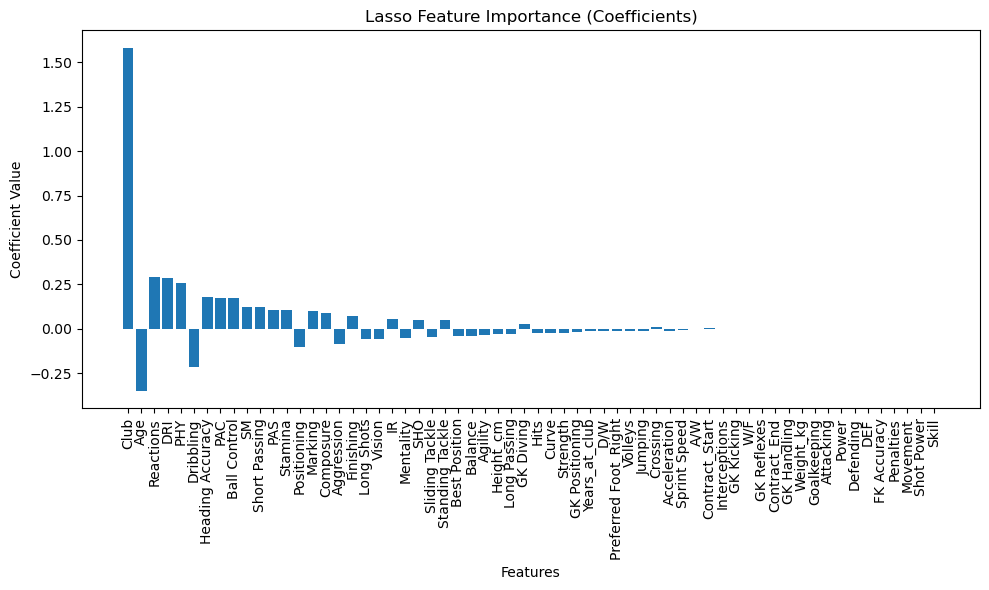

In [22]:
lasso = Lasso(alpha=0.001, random_state=3)
lasso.fit(X_train_scaled, y_train)

coefficients = lasso.coef_
features = X_train.columns

indices = np.argsort(np.abs(coefficients))[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(coefficients)), coefficients[indices])
plt.xticks(range(len(coefficients)), features[indices], rotation=90)
plt.title("Lasso Feature Importance (Coefficients)")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.tight_layout()
plt.show()

In [23]:
zero_features = X_train.columns[lasso.coef_ == 0]

print("Features removed by Lasso (coefficients = 0):\n")
print(list(zero_features))

Features removed by Lasso (coefficients = 0):

['Weight_kg', 'Attacking', 'Skill', 'FK Accuracy', 'Movement', 'Power', 'Shot Power', 'Penalties', 'Defending', 'Goalkeeping', 'GK Handling', 'GK Reflexes', 'DEF', 'Contract_End']


In [24]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

print("Best alpha:", lasso.alpha_)

Best alpha: 0.0017376015564818466


## Evaluation of K-Nearest Neighbors (KNN)

The K-Nearest Neighbors (KNN) regression model was evaluated using a combination of hyperparameter tuning and cross-validation techniques to ensure reliable performance.

Initially, GridSearchCV was applied to identify the optimal hyperparameters, including the number of neighbors (k), distance metric, and weighting strategy. This allowed systematic exploration of different configurations and selection of the best-performing model based on R² score.

After identifying the best parameters, the model was further evaluated using K-Fold cross-validation. The dataset was split into multiple folds, and the model was trained and validated across different subsets to assess its consistency and generalization ability.

The R² score was used as the primary evaluation metric, as it measures how well the model explains the variance in the target variable. This approach ensured that the performance of KNN was not dependent on a single train-test split but was stable across multiple data partitions.

Overall, this evaluation strategy provided a robust estimate of the model’s performance and helped in comparing it effectively with other models used in the project.


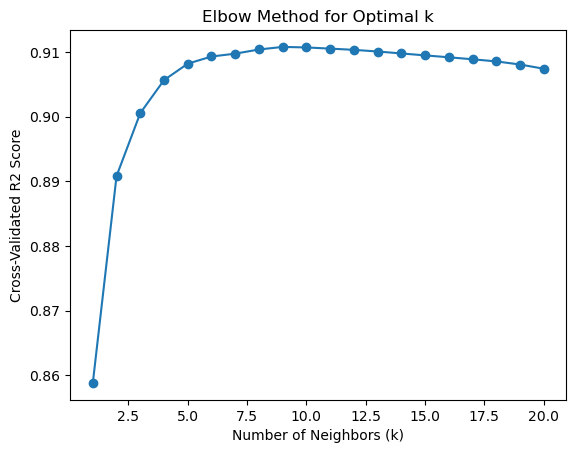

Optimal k from Elbow Method: 9


In [25]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold, cross_val_score


k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="r2", n_jobs=-1)
    cv_scores.append(scores.mean())

# Plot
plt.figure()
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validated R2 Score")
plt.title("Elbow Method for Optimal k")
plt.show()

# Best k
best_k = k_values[np.argmax(cv_scores)]
print("Optimal k from Elbow Method:", best_k)

In [26]:
# 🔹 Define parameter grid (removed n_neighbors)
param_grid = {
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

# 🔹 Base model with best_k
knn = KNeighborsRegressor(n_neighbors=best_k)

# 🔹 Grid Search
grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

# 🔹 Best model
best_knn = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'metric': 'euclidean', 'weights': 'distance'}
Best CV Score: 0.9114052703446497


In [27]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []

for train_idx, val_idx in kf.split(X_train_scaled):
    
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    best_knn.fit(X_tr, y_tr)
    y_pred = best_knn.predict(X_val)
    
    r2_scores.append(r2_score(y_val, y_pred))

print("R2 Scores:", r2_scores)
print("Mean R2:", np.mean(r2_scores))

R2 Scores: [0.944764054045476, 0.9073020378667367, 0.8714505136466898, 0.917633682532283, 0.9131821767247705]
Mean R2: 0.9108664929631912


## Why Polynomial Regression?

Linear Regression assumes a linear relationship between features and target.

However, real-world data often contains non-linear patterns.

Polynomial Regression introduces interaction and higher-order terms, allowing the model to capture non-linear relationships.

This helps evaluate whether the dataset benefits from non-linear transformations.

In [28]:
from sklearn.preprocessing import PolynomialFeatures

# Polynomial transformer
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transform ONLY training data first
X_train_poly = poly.fit_transform(X_train_scaled)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []

for train_idx, val_idx in kf.split(X_train_poly):
    X_tr, X_val = X_train_poly[train_idx], X_train_poly[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)

    r2_scores.append(r2_score(y_val, y_pred))

print("R2 Scores:", r2_scores)
print("Mean R2:", np.mean(r2_scores))

R2 Scores: [0.9737050336653933, 0.9577525914205987, 0.9269613471425157, 0.966475789851051, 0.9563289621879795]
Mean R2: 0.9562447448535074


## Why Decision Tree?

Decision Trees:
- Capture non-linear relationships
- Handle feature interactions automatically
- Do not require feature scaling
- Are interpretable compared to ensemble models

However, they are prone to overfitting, so pruning and hyperparameter tuning are essential.

In [29]:
from sklearn.tree import DecisionTreeRegressor,plot_tree

dt = DecisionTreeRegressor(random_state=42)

param_dist = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", None]
}

In [30]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,  # internal CV for tuning
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_dt = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

Best Parameters: {'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 20}


In [31]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    best_dt.fit(X_tr, y_tr)
    y_pred = best_dt.predict(X_val)

    r2_scores.append(r2_score(y_val, y_pred))

print("R2 Scores:", r2_scores)
print("Mean R2:", np.mean(r2_scores))


R2 Scores: [0.9595328013654302, 0.9277235862654931, 0.8919215730960256, 0.9422531687388971, 0.9404277756250248]
Mean R2: 0.9323717810181741


## Why Random Forest?

Random Forest is an ensemble of Decision Trees that:
- Reduces overfitting by averaging multiple trees
- Captures non-linear relationships
- Handles feature interactions automatically
- Is robust to multicollinearity

It generally provides better generalization than a single Decision Tree.

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# 🔹 Define parameter grid
param_dist = {
    "n_estimators": [100, 150, 200, 250, 300],
    "max_depth": [10, 15, 20, 25, 30],
    "min_samples_split": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "max_features": ["sqrt", "log2", None]
}


rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)


random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,                 
    scoring="r2",
    cv=3,
    verbose=2,                 
    random_state=42,
    n_jobs=-1
)


random_search.fit(X_train, y_train)

# 🔹 Best model
best_rf = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}
Best Score: 0.9645773988623264


## Hyperparameter Tuning using RandomizedSearchCV

Hyperparameter tuning was performed using RandomizedSearchCV instead of GridSearchCV to decrease the time taking.

GridSearchCV evaluates all possible combinations of hyperparameters, which can be computationally expensive, especially when the search space is large.

In contrast, RandomizedSearchCV samples a fixed number of parameter combinations from the search space. This allows faster exploration while still covering a wide range of values.

Although GridSearchCV guarantees finding the optimal combination within the defined grid, RandomizedSearchCV provides a good trade-off between performance and computational cost.

Therefore, RandomizedSearchCV was chosen as it significantly reduces training time while still achieving strong model performance.

In [33]:
from sklearn.base import clone

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = clone(best_rf)  
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)

    r2_scores.append(r2_score(y_val, y_pred))

print("R2 Scores:", r2_scores)
print("Mean R2:", np.mean(r2_scores))
print("Std Dev:", np.std(r2_scores))

R2 Scores: [0.9833598790632799, 0.9594489763058466, 0.9254690759279851, 0.9739432142153097, 0.9709456490095159]
Mean R2: 0.9626333589043874
Std Dev: 0.020089399461043066


In [34]:

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Keep only meaningful features
selected_features = importance[importance["Importance"] > 0.002]["Feature"]

X_train_filtered = X_train[selected_features]
X_test_filtered = X_test[selected_features]

print("Selected Features:", len(selected_features))
print(selected_features)

Selected Features: 13
1             Club
57            Hits
21       Reactions
0              Age
16    Ball Control
36       Defending
54             DRI
55             DEF
40     Goalkeeping
56             PHY
51             PAC
52             SHO
5        Attacking
Name: Feature, dtype: object


## Feature Engineering using Embedded Method (Feature Importance)

Feature selection was performed using an embedded method based on the Random Forest model.

Unlike filter or wrapper methods, embedded methods perform feature selection as part of the model training process.

In this approach:
- A Random Forest model was trained on the dataset
- Feature importance scores were extracted using the `feature_importances_` attribute
- Features with higher importance were retained, while low-impact features were removed

### Selected Features

The model identified the following key features:

- Club  
- Hits  
- Reactions  
- Age  
- Ball Control  
- Defending  
- DRI  
- DEF  
- PHY  
- SHO  
- Goalkeeping  

### Insights

- **Club and Hits** indicate the influence of market dynamics and popularity
- **Reactions and Ball Control** highlight technical ability
- **Aggregate features (DRI, DEF, PHY, SHO)** capture overall player performance

This method reduced the feature space while maintaining (or slightly improving) model performance, demonstrating that a smaller subset of features can effectively represent the predictive signal.

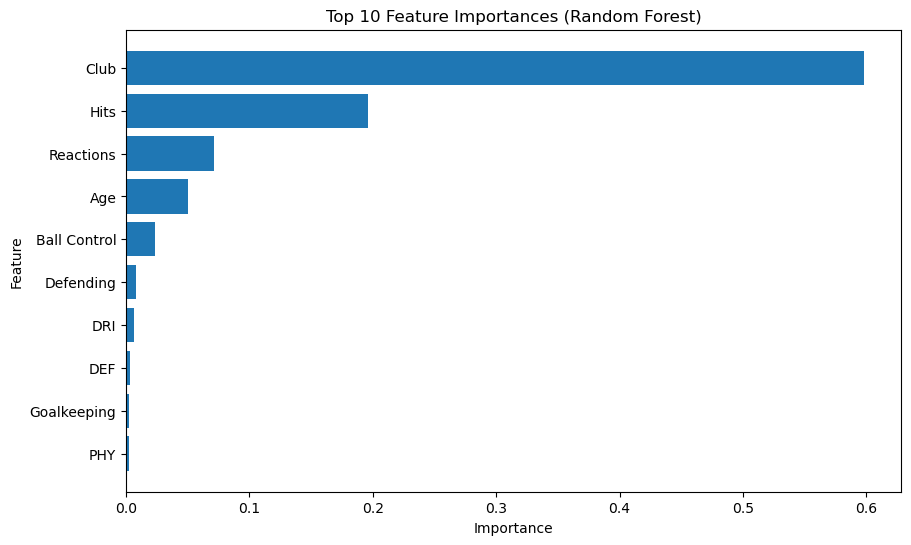

In [35]:
# Create dataframe
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

## Feature Importance Interpretation

The Club feature shows a high importance (~59%), indicating that it strongly influences player market value.

This is not due to data leakage, but because club reputation, financial strength, and visibility significantly affect player valuation in real-world scenarios.

While this improves predictive performance, it also means that the model relies more on contextual information than purely on player skills.

This highlights an important trade-off between accuracy and interpretability in machine learning models.

In [36]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train_filtered.iloc[train_idx], X_train_filtered.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    best_rf.fit(X_tr, y_tr)
    y_pred = best_rf.predict(X_val)

    r2_scores.append(r2_score(y_val, y_pred))

print("R2 Scores:", r2_scores)
print("Mean R2:", np.mean(r2_scores))
print("Std Dev:", np.std(r2_scores))

R2 Scores: [0.9831801102645138, 0.9597196173993509, 0.9250747508948811, 0.9749223243371461, 0.9717295903691322]
Mean R2: 0.9629252786530047
Std Dev: 0.020369791011173213


# 📊 t-SNE Visualization

## 🔍 Why t-SNE?

t-SNE is used to reduce ***high-dimensional data*** into ***2D*** while preserving local relationships. It helps visualize hidden patterns and understand how similar data points are grouped together.

## 📈 Observations

- Clear clusters are visible, indicating structured feature space
- Player value (color) is highly overlapping across clusters
- Some isolated points suggest presence of outliers
  
## 🧠 Interpretation

Player value does not form clearly separable groups, indicating it depends on complex, non-linear combinations of features.

## ✅ Conclusion

t-SNE confirms meaningful structure in the data and justifies the use of advanced machine learning models for prediction.

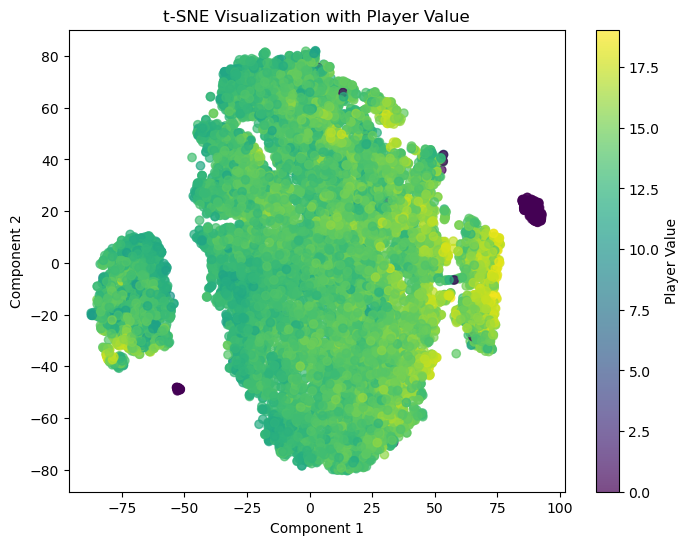

In [37]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X_tsne = tsne.fit_transform(X_train_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_train, cmap='viridis', alpha=0.7)
plt.colorbar(label="Player Value")
plt.title("t-SNE Visualization with Player Value")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

## Model Comparison and Final Selection

Multiple machine learning models were implemented and evaluated to predict player market value. Each model provided different insights into the dataset and its underlying relationships.

---

## Model Performance Summary

| Model                 | R² Score           | Key Strength                              | Limitation                                       |
| --------------------- | ------------------ | ----------------------------------------- | ------------------------------------------------ |
| Linear Regression     | ~0.90–0.91         | Simple, interpretable                     | Cannot capture non-linearity  
|
| Lasso Regression      | Lower (~0.85–0.90) | Feature selection, reduces complexity     | May remove useful features                       |
| KNN                   | ~0.91              | Captures local similarity                 | Sensitive to scaling, weaker on complex patterns |
| Polynomial Regression | ~0.95–0.96         | Captures complex relationships            | High dimensionality, risk of overfitting         |
| Decision Tree         | ~0.93              | Non-linear modeling, interpretable        | Prone to overfitting                             |
| Random Forest         | ~0.96              | High accuracy, stable, handles complexity | Less interpretable                               |


---

## Observations

* **Linear Regression** served as a strong baseline but failed to capture non-linear relationships.
* **Polynomial Regression** improved performance but introduced excessive complexity and reduced interpretability.
* **Decision Tree** captured non-linearity but lacked stability.
* **Random Forest** provided the best balance of performance and generalization.
* **Lasso Regression** helped identify important features by eliminating irrelevant ones, improving interpretability.
* **KNN** showed that similar players tend to have similar values, but it struggled with capturing global patterns.

---

## Why Random Forest Was Selected

Random Forest was chosen as the final model because:

* It achieved the highest R² score
* It showed consistent performance across K-Fold validation
* It effectively captured non-linear relationships
* It handled feature interactions without increasing dimensionality
* It reduced overfitting compared to simpler models

---

## Final Conclusion

The experiments demonstrate that player valuation depends on complex, non-linear relationships between features.

While simpler models provide interpretability and insights, ensemble methods like Random Forest are better suited for capturing real-world data complexity.

---

## Final Insight

This project highlights that:

* Model selection is as important as feature engineering
* Different models reveal different aspects of the data
* Ensemble methods are highly effective for structured real-world datasets
* A combination of predictive modeling and decision logic leads to practical applications

This reflects a complete and industry-aligned machine learning workflow.


In [ ]:
## just to showcase not a part of the project 

import tkinter as tk
from tkinter import ttk
import numpy as np
import pandas as pd

# =========================
# 🔹 PRECOMPUTATION (ML LOGIC)
# =========================

data = X_train.copy()

X_full = data[selected_features].copy()
log_preds = best_rf.predict(X_full)

data["Predicted_Value"] = np.expm1(log_preds)

# Remove bottom 10% (bad predictions)
threshold = data["Predicted_Value"].quantile(0.1)
data = data[data["Predicted_Value"] > threshold]

# Add original names
data["Name"] = df.loc[data.index, "Name"]

# Performance score
data["Performance"] = (
    data["Reactions"] +
    data["Ball Control"] +
    data["Finishing"] +
    data["Positioning"] +
    data["Vision"]
)

# Normalize
data["Performance_Norm"] = data["Performance"] / data["Performance"].max()
data["Value_Norm"] = data["Predicted_Value"] / data["Predicted_Value"].max()

# Final score
data["Score"] = data["Performance_Norm"] - data["Value_Norm"]

def recommend_players(data, budget, position="All", top_n=10):
    filtered = data[data["Predicted_Value"] <= budget].copy()

    if position != "All":
        # use original position from df
        filtered = filtered[df.loc[filtered.index, "Best Position"] == position]

    # Take top 50 then randomize → avoids same results always
    filtered = filtered.sort_values(by="Score", ascending=False).head(50)

    if len(filtered) > top_n:
        filtered = filtered.sample(n=top_n, random_state=None)

    return filtered

def get_recommendations():
    budget = budget_var.get()
    position = position_var.get()

    results = recommend_players(data, budget, position)

    # Clear table
    for row in tree.get_children():
        tree.delete(row)

    # Insert results
    for _, row in results.iterrows():
        tree.insert("", "end", values=(
            row["Name"],
            df.loc[row.name, "Best Position"],  # FIXED (original value)
            f"{int(row['Predicted_Value']):,}",
            int(row["Performance"]),
            round(row["Score"], 3)
        ))


root = tk.Tk()
root.title("⚽ Player Recommendation System")
root.geometry("950x550")
root.configure(bg="#1e1e2f")

# Title
title = tk.Label(root, text="⚽ AI Player Recommendation",
                 font=("Arial", 20, "bold"),
                 fg="white", bg="#1e1e2f")
title.pack(pady=10)

# Controls
frame = tk.Frame(root, bg="#1e1e2f")
frame.pack(pady=10)

# Budget
tk.Label(frame, text="Budget (€):", fg="white", bg="#1e1e2f").grid(row=0, column=0, padx=10)

budget_var = tk.IntVar(value=50000000)
budget_scale = tk.Scale(frame, from_=100000, to=100000000,
                        orient="horizontal", length=300,
                        variable=budget_var)
budget_scale.grid(row=0, column=1)

# Position dropdown (use original df)
tk.Label(frame, text="Position:", fg="white", bg="#1e1e2f").grid(row=0, column=2, padx=10)

positions = ["All"] + sorted(df["Best Position"].unique().tolist())
position_var = tk.StringVar(value="All")

position_menu = ttk.Combobox(frame, textvariable=position_var, values=positions)
position_menu.grid(row=0, column=3)

# Button
btn = tk.Button(root, text="Get Recommendations",
                command=get_recommendations,
                bg="#4CAF50", fg="white", font=("Arial", 12))
btn.pack(pady=10)

# Table
columns = ("Name", "Position", "Value (€)", "Performance", "Score")

tree = ttk.Treeview(root, columns=columns, show="headings", height=15)

for col in columns:
    tree.heading(col, text=col)
    tree.column(col, anchor="center")

tree.pack(fill="both", expand=True, padx=20, pady=10)

# Run
root.mainloop()

[CV] END max_depth=20, max_features=None, min_samples_leaf=5, min_samples_split=6, n_estimators=100; total time=  17.5s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=3, min_samples_split=2, n_estimators=200; total time=   4.2s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=3, min_samples_split=2, n_estimators=200; total time=   4.3s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=3, min_samples_split=2, n_estimators=200; total time=   4.2s
[CV] END max_depth=15, max_features=None, min_samples_leaf=2, min_samples_split=2, n_estimators=150; total time=  27.7s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=4, n_estimators=150; total time=   3.3s
[CV] END max_depth=25, max_features=None, min_samples_leaf=3, min_samples_split=10, n_estimators=150; total time=  27.5s
[CV] END max_depth=15, max_features=None, min_samples_leaf=2, min_samples_split=2, n_estimators=150; total time=  27.6s
[CV] END max_depth=30, max_features=log